In [1]:
import os
import torch
import kagglehub
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
path = kagglehub.dataset_download("someshjoshidsai007/dataset")

print("Dataset path:", path)

Dataset path: /kaggle/input/datasets/someshjoshidsai007/dataset


In [3]:
image_dir = os.path.join(path, "dataset/images")
csv_path = os.path.join(path, "dataset/annotations/fashion_cvae_labels.csv")

In [4]:
import kagglehub

# Download latest version
path = kagglehub.model_download("someshjoshidsai007/cvae-checkpoint-fashion-dataset/pyTorch/10_epochs")

print("Path to model files:", path)

Path to model files: /kaggle/input/models/someshjoshidsai007/cvae-checkpoint-fashion-dataset/pytorch/10_epochs/2


In [5]:
checkpoint_path = "/kaggle/input/models/someshjoshidsai007/cvae-checkpoint-fashion-dataset/pytorch/10_epochs/2/best_cvae.pth"

In [6]:
df = pd.read_csv(csv_path)

# convert bool → int
df = df.astype({col: "int" for col in df.columns if col != "id"})

In [7]:
df["image_path"] = df["id"].apply(
    lambda x: os.path.join(image_dir, f"{x}.jpg")
)

df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

print("Dataset size:", len(df))

Dataset size: 11409


In [8]:
df.head()

,id,gender_Men,gender_Unisex,gender_Women,articleType_Jeans,articleType_Shirts,articleType_Trousers,articleType_Tshirts,baseColour_Beige,baseColour_Black,...,baseColour_Purple,baseColour_Red,baseColour_Teal,baseColour_White,baseColour_Yellow,season_Fall,season_Spring,season_Summer,season_Winter,image_path
0,15970,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,/kaggle/input/datasets/someshjoshidsai007/data...
1,39386,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,/kaggle/input/datasets/someshjoshidsai007/data...
2,53759,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,/kaggle/input/datasets/someshjoshidsai007/data...
3,1855,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,/kaggle/input/datasets/someshjoshidsai007/data...
4,30805,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,/kaggle/input/datasets/someshjoshidsai007/data...


In [9]:
df.describe()

,id,gender_Men,gender_Unisex,gender_Women,articleType_Jeans,articleType_Shirts,articleType_Trousers,articleType_Tshirts,baseColour_Beige,baseColour_Black,...,baseColour_Pink,baseColour_Purple,baseColour_Red,baseColour_Teal,baseColour_White,baseColour_Yellow,season_Fall,season_Spring,season_Summer,season_Winter
count,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,...,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000,11409.000000
mean,20827.376895,0.831011,0.006661,0.162328,0.052765,0.281532,0.046455,0.619248,0.013936,0.136734,...,0.034271,0.048383,0.091331,0.002454,0.155667,0.034622,0.414234,0.009729,0.557805,0.018231
std,14777.948611,0.374759,0.081349,0.368768,0.223575,0.449766,0.210477,0.485593,0.117232,0.343582,...,0.181933,0.214583,0.288092,0.049481,0.362555,0.182828,0.492611,0.098160,0.496669,0.133792
min,1163.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8780.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,16529.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,31162.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,59894.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [11]:
class FashionDataset(Dataset):

    def __init__(self, df, transform=None):

        self.paths = df["image_path"].values
        self.conditions = df.drop(columns=["id","image_path"]).values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        image = Image.open(self.paths[idx]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        condition = torch.tensor(
            self.conditions[idx],
            dtype=torch.float32
        )

        return image, condition

In [12]:
dataset = FashionDataset(df, transform)

In [13]:
loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [14]:
images, cond = next(iter(loader))

print(images.shape)
print(cond.shape)

torch.Size([64, 3, 128, 128])
torch.Size([64, 30])


In [15]:
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

In [16]:
class Encoder(nn.Module):

    def __init__(self, condition_dim=30, latent_dim=128):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,4,2,1),
            nn.ReLU(),

            nn.Conv2d(32,64,4,2,1),
            nn.ReLU(),

            nn.Conv2d(64,128,4,2,1),
            nn.ReLU(),

            nn.Conv2d(128,256,4,2,1),
            nn.ReLU()
        )

        self.fc = nn.Linear(256*8*8 + condition_dim,512)

        self.mu = nn.Linear(512,latent_dim)
        self.logvar = nn.Linear(512,latent_dim)

    def forward(self,x,c):

        x = self.conv(x)
        x = x.view(x.size(0),-1)

        x = torch.cat([x,c],dim=1)

        x = F.relu(self.fc(x))

        mu = self.mu(x)
        logvar = self.logvar(x)

        return mu,logvar

In [17]:
def reparameterize(mu,logvar):

    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)

    return mu + eps*std

In [18]:
class Decoder(nn.Module):

    def __init__(self,condition_dim=30,latent_dim=128):
        super().__init__()

        self.fc = nn.Linear(latent_dim+condition_dim,256*8*8)

        self.deconv = nn.Sequential(

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(32,3,4,2,1),
            nn.Sigmoid()
        )

    def forward(self,z,c):

        z = torch.cat([z,c],dim=1)

        x = self.fc(z)
        x = x.view(-1,256,8,8)

        x = self.deconv(x)

        return x

In [19]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class Encoder(nn.Module):
#     def __init__(self, condition_dim=30, latent_dim=128):
#         super().__init__()

#         # Added BatchNorm and switched to LeakyReLU for better gradient flow
#         self.conv = nn.Sequential(
#             nn.Conv2d(3, 32, 4, 2, 1),
#             nn.BatchNorm2d(32),
#             nn.LeakyReLU(0.2),

#             nn.Conv2d(32, 64, 4, 2, 1),
#             nn.BatchNorm2d(64),
#             nn.LeakyReLU(0.2),

#             nn.Conv2d(64, 128, 4, 2, 1),
#             nn.BatchNorm2d(128),
#             nn.LeakyReLU(0.2),

#             nn.Conv2d(128, 256, 4, 2, 1),
#             nn.BatchNorm2d(256),
#             nn.LeakyReLU(0.2)
#         )

#         # Increased capacity in the fully connected layer
#         self.fc = nn.Linear(256 * 8 * 8 + condition_dim, 512)
#         self.mu = nn.Linear(512, latent_dim)
#         self.logvar = nn.Linear(512, latent_dim)

#     def forward(self, x, c):
#         x = self.conv(x)
#         x = x.view(x.size(0), -1)
        
#         # Concatenate condition
#         x = torch.cat([x, c], dim=1)
#         x = F.leaky_relu(self.fc(x), 0.2)

#         mu = self.mu(x)
#         logvar = self.logvar(x)

#         return mu, logvar

# def reparameterize(mu, logvar):
#     # Clamp logvar to prevent it from reaching infinity/NaN
#     logvar = torch.clamp(logvar, -10, 10) 
#     std = torch.exp(0.5 * logvar)
#     eps = torch.randn_like(std)
#     return mu + eps * std

# class Decoder(nn.Module):
#     def __init__(self, condition_dim=30, latent_dim=128):
#         super().__init__()

#         self.fc = nn.Linear(latent_dim + condition_dim, 256 * 8 * 8)

#         self.deconv = nn.Sequential(
#             # Added BatchNorm to stabilize fashion item reconstruction
#             nn.ConvTranspose2d(256, 128, 4, 2, 1),
#             nn.BatchNorm2d(128),
#             nn.LeakyReLU(0.2),

#             nn.ConvTranspose2d(128, 64, 4, 2, 1),
#             nn.BatchNorm2d(64),
#             nn.LeakyReLU(0.2),

#             nn.ConvTranspose2d(64, 32, 4, 2, 1),
#             nn.BatchNorm2d(32),
#             nn.LeakyReLU(0.2),

#             nn.ConvTranspose2d(32, 3, 4, 2, 1),
#             nn.Sigmoid() 
#         )

#     def forward(self, z, c):
#         z = torch.cat([z, c], dim=1)
#         x = self.fc(z)
#         x = x.view(-1, 256, 8, 8)
#         x = self.deconv(x)
#         return x

In [20]:
class CVAE(nn.Module):

    def __init__(self,condition_dim=30,latent_dim=128):
        super().__init__()

        self.encoder = Encoder(condition_dim,latent_dim)
        self.decoder = Decoder(condition_dim,latent_dim)

    def forward(self,x,c):

        mu,logvar = self.encoder(x,c)

        z = reparameterize(mu,logvar)

        recon = self.decoder(z,c)

        return recon,mu,logvar

In [21]:
def loss_function(recon_x,x,mu,logvar):

    recon_loss = F.mse_loss(recon_x,x,reduction="sum")

    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl

In [22]:
# def loss_function(recon_x, x, mu, logvar):

#     recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")

#     kl = -0.5 * torch.sum(
#         1 + logvar - mu.pow(2) - logvar.exp()
#     )

#     return (recon_loss + kl) / x.size(0)

In [23]:
# def loss_function(recon_x, x, mu, logvar, beta=0.0005):

#     recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")

#     kl = -0.5 * torch.sum(
#         1 + logvar - mu.pow(2) - logvar.exp()
#     )

#     return (recon_loss + beta * kl) / x.size(0)

In [24]:
# def loss_function(recon_x, x, mu, logvar):
#     # 1. Reconstruction Loss (How well does it look like the original?)
#     # Using BCE if your output is Sigmoid, otherwise MSE
#     recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

#     # 2. KL Divergence (How well does the latent space follow a Normal Distribution?)
#     # This prevents the model from just "memorizing" the images
#     kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

#     return recon_loss + kl_loss

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = CVAE().to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=1e-2)

In [26]:
device

'cuda'

In [27]:
checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Pretrained checkpoint loaded successfully!")

Pretrained checkpoint loaded successfully!


In [28]:
!ls /kaggle/working

In [29]:
checkpoint = torch.load("/kaggle/working/best_cvae_fashion.pth")

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

model.to(device)

print("Best model loaded successfully")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/best_cvae_fashion.pth'

In [70]:
from tqdm import tqdm

epochs = 30
best_loss = float("inf")

for epoch in range(epochs):

    model.train()
    total_loss = 0

    progress_bar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, cond in progress_bar:

        images = images.to(device)
        cond = cond.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(images, cond)

        loss = loss_function(recon, images, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(batch_loss=loss.item())

    avg_loss = total_loss / len(loader)

    print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")

    # Save best model
    if avg_loss < best_loss:

        best_loss = avg_loss

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        }, "/kaggle/working/best_cvae_fashion.pth")

        print("✅ Best model saved")

    # Save latest checkpoint
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, "/kaggle/working/cvae_checkpoint.pth")

Epoch 1/30: 100%|██████████| 179/179 [03:49<00:00,  1.28s/it, batch_loss=nan]  


Epoch 1 Average Loss: nan


Epoch 2/30: 100%|██████████| 179/179 [03:44<00:00,  1.26s/it, batch_loss=nan]


Epoch 2 Average Loss: nan


Epoch 3/30: 100%|██████████| 179/179 [03:47<00:00,  1.27s/it, batch_loss=nan]


Epoch 3 Average Loss: nan


Epoch 4/30: 100%|██████████| 179/179 [03:47<00:00,  1.27s/it, batch_loss=nan]


Epoch 4 Average Loss: nan


Epoch 5/30:  39%|███▉      | 70/179 [01:29<02:19,  1.28s/it, batch_loss=nan]


KeyboardInterrupt: 

In [30]:
model.eval()

CVAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU()
    )
    (fc): Linear(in_features=16414, out_features=512, bias=True)
    (mu): Linear(in_features=512, out_features=128, bias=True)
    (logvar): Linear(in_features=512, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=158, out_features=16384, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): ConvTranspose2d(64, 32, ke

In [31]:
gender_map = {
    "Men": 0,
    "Unisex": 1,
    "Women": 2
}

article_map = {
    "Jeans": 3,
    "Shirts": 4,
    "Trousers": 5,
    "Tshirts": 6
}

color_map = {
    "Beige":7,
    "Black":8,
    "Blue":9,
    "Brown":10,
    "Fluorescent Green":11,
    "Gold":12,
    "Green":13,
    "Grey":14,
    "Lavender":15,
    "Magenta":16,
    "Multi":17,
    "Mushroom Brown":18,
    "Orange":19,
    "Pink":20,
    "Purple":21,
    "Red":22,
    "Teal":23,
    "White":24,
    "Yellow":25
}

season_map = {
    "Fall":26,
    "Spring":27,
    "Summer":28,
    "Winter":29
}

In [32]:
import matplotlib.pyplot as plt

def generate_outfit(model, gender, article, color, season, n_samples=8):

    model.eval()

    condition = torch.zeros(30)

    condition[gender_map[gender]] = 1
    condition[article_map[article]] = 1
    condition[color_map[color]] = 1
    condition[season_map[season]] = 1

    z = torch.randn(n_samples,128).to(device)

    cond = condition.unsqueeze(0).repeat(n_samples,1).to(device)

    with torch.no_grad():
        images = model.decoder(z, cond)

    images = images.cpu()

    fig, axes = plt.subplots(1,n_samples, figsize=(15,4))

    for i in range(n_samples):

        img = images[i].permute(1,2,0)

        axes[i].imshow(img)
        axes[i].axis("off")

    plt.show()

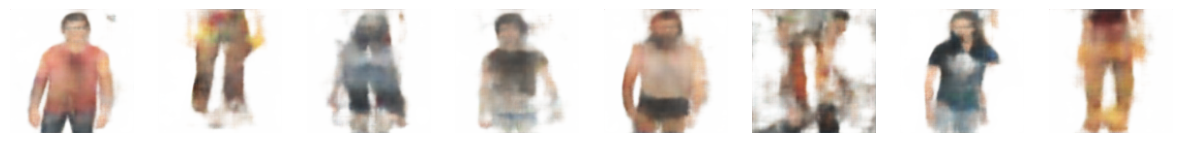

In [33]:
generate_outfit(
    model,
    gender="Women",
    article="Jeans",
    color="Orange",
    season="Winter"
)

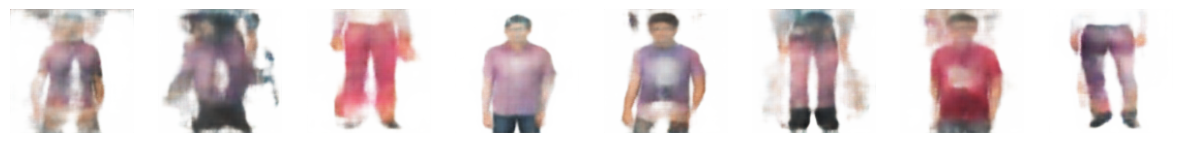

In [34]:
generate_outfit(
    model,
    gender="Men",
    article="Trousers",
    color="Pink",
    season="Fall"
)